# Danish Food Safety — Explainer Notebook

This notebook documents all data analysis behind the project website on Danish food safety inspection results (Smiley-scheme data from Fødevarestyrelsen).

---


# 1 - Motivation
- what is your dataset?
- Why did you choose this data?
- What was your goal for the end users experience?

## 1. Motivation

### What is the dataset?
The dataset is the **Danish Smiley scheme** — Fødevarestyrelsen's (Danish Veterinary and Food Administration) public database of food safety inspection results. Every food business in Denmark is subject to unannounced inspections and receives a score from 1 (no remarks) to 4 (serious — risk of shutdown). The results are published openly and displayed as a physical smiley poster in every food establishment. The full dataset is accessible via the Fødevarestyrelsen API and contains up to the four most recent inspections per business.

### Why did we choose this dataset?
The starting point was a simple, practical question: where is it safe to eat in Denmark, and are there patterns in where things go wrong? We wanted to know whether certain types of places, or certain areas of the country, had noticeably more or fewer issues — and whether any of it was surprising.
Denmark's food safety system is also uniquely transparent: inspection results are public, searchable, and updated continuously. That made it possible to study compliance at scale — across business types, geographic areas, and over time. When a business does fail an inspection, does the system actually correct behaviour? We wanted to find out.

### What was our goal for the end user experience?
We wanted to make the findings accessible to anyone — not just Danes. While the Smiley scheme is well known locally (it has been mandatory since 2001 and most Danes will recognise the poster in restaurant windows), many people — including international students and visitors — have no idea the system exists or what it means. Our goal was a clean, story-driven website that explains the system briefly and then lets the data speak: start with the overall picture, then progressively reveal where risk concentrates.


# 2 - Basic Stats
- Write about choices in datacleaning and preprocessing
- Write a short section discussin datasets stats containing key points/plot from exploratory data analysis

## 2.1 Data cleaning

## 2. Basic Stats

### 2.1 Data Cleaning and Preprocessing


In [1]:
!pip install pandas openpyxl matplotlib seaborn --quiet



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load raw data
df_raw = pd.read_excel('data/smileystatus.xlsx')
print(f'Raw shape: {df_raw.shape}')
df_raw.info()

Raw shape: (58396, 23)
<class 'pandas.DataFrame'>
RangeIndex: 58396 entries, 0 to 58395
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   navnelbnr                   58396 non-null  int64         
 1   cvrnr                       57304 non-null  float64       
 2   pnr                         57040 non-null  float64       
 3   brancheKode                 58396 non-null  str           
 4   branche                     58396 non-null  str           
 5   virksomhedstype             58396 non-null  str           
 6   navn1                       58396 non-null  str           
 7   adresse1                    58396 non-null  str           
 8   postnr                      58396 non-null  int64         
 9   By                          57468 non-null  str           
 10  seneste_kontrol             51847 non-null  float64       
 11  seneste_kontrol_dato        51849 non-null

The raw data is in **wide format** — each row is a business with up to four inspection columns (`seneste_kontrol`, `naestseneste_kontrol`, etc.) plus corresponding date columns. We reshape to long format so each row is a single inspection.

In [7]:
# Start by unpivoting so one kontrol per line
df = df_raw.rename(columns={
    "seneste_kontrol": "kontrol_1",
    "seneste_kontrol_dato": "dato_1",
    "naestseneste_kontrol": "kontrol_2",
    "naestseneste_kontrol_dato": "dato_2",
    "tredjeseneste_kontrol": "kontrol_3",
    "tredjeseneste_kontrol_dato": "dato_3",
    "fjerdeseneste_kontrol": "kontrol_4",
    "fjerdeseneste_kontrol_dato": "dato_4"
})

# Reshape: wide -> long
df = (
    pd.wide_to_long(
        df,
        stubnames=["kontrol", "dato"],
        i="navnelbnr",
        j="tjek_nr",
        sep="_"
    )
    .reset_index()
)

# Drop rows with no inspection and parse dates
df = df.dropna(subset=["kontrol", "dato"])
df["dato"] = pd.to_datetime(df["dato"])

# Remove nonsense scores (0.0 appears in raw data)
df = df[df['kontrol'] != 0.0]

# Remove unused columns
df = df.drop(columns=['Elite_Smiley', 'brancheKode', 'reklame_beskyttelse'], errors='ignore')

print(f'Long format shape: {df.shape}')
df.head()


Long format shape: (167591, 15)


,navnelbnr,tjek_nr,By,Geo_Lat,Geo_Lng,URL,adresse1,branche,cvrnr,navn1,pnr,postnr,virksomhedstype,kontrol,dato
0,513605,1,København SV,55.656613,12.537889,http://www.findsmiley.dk/da-DK/Searching/Detai...,Enghavevej 172,Specialforretning - Bager m.v.,34583730.0,Firdaws ApS,1.017699e+09,2450,Detail,1.0,2024-09-27
1,26029,1,Brønderslev,57.270705,9.950767,http://www.findsmiley.dk/da-DK/Searching/Detai...,Dannebrogsgade 21,Specialforretning - Bager m.v.,18043041.0,KonditorBager,1.001418e+09,9700,Detail,1.0,2022-05-03
2,69750,1,Give,55.844766,9.237281,http://www.findsmiley.dk/da-DK/Searching/Detai...,Nytorv 1,Specialforretning - Bager m.v.,21467782.0,NYTORVS BAGERI APS,1.004954e+09,7323,Detail,1.0,2025-01-16
3,555571,1,Havdrup,55.543675,12.115530,http://www.findsmiley.dk/da-DK/Searching/Detai...,Møllemarken 6,Specialforretning - Bager m.v.,18623978.0,SuperBrugsen Havdrup Bageri,1.019633e+09,4622,Detail,1.0,2025-04-08
4,1292639,1,Højer,NaN,NaN,http://www.findsmiley.dk/da-DK/Searching/Detai...,Storegade 20 stuen,Specialforretning - Bager m.v.,43771930.0,Digebageren,1.028920e+09,6280,Detail,1.0,2025-01-28


#### Date filtering
The Smiley systematic digital coverage only began in 2012. We remove everything before 2012 to avoid artifacts from the rollout period. See [Fødevarestyrelsen's documentation](https://www.findsmiley.dk/om_smiley/info_til_forbrugere/Sider/Generelt/Alle_kontrolrapporter_paa_nettet.aspx) for context.


In [8]:
# Inspect year distribution
print('Inspections per year (all time):')
print(df.groupby(df['dato'].dt.year)['kontrol'].size().to_string())

Inspections per year (all time):
dato
2003        1
2004       82
2005      145
2006      231
2007      296
2008      247
2009      334
2010      334
2011      443
2012      387
2013      519
2014      938
2015     1376
2016     2680
2017     3977
2018     6541
2019     9200
2020     6443
2021    10485
2022    16200
2023    25162
2024    31777
2025    37403
2026    12390


In [9]:
# Filter to 2012+
df = df[df['dato'].dt.year >= 2012]
print(f'After 2012 filter: {len(df):,} inspection records')
print(f'Unique businesses:  {df["navnelbnr"].nunique():,}')


After 2012 filter: 165,478 inspection records
Unique businesses:  51,715


#### Category mapping
The raw `branche` column contains ~50 Danish category names. We map them to 7 English-language macro groups for analysis and visualisation.


In [ ]:
# Now lets look at categories of restaurants
print(f'There are {len(df["branche"].unique())} unique branches in this dataset')

# Lets look at how many inspections are in each branche
df["branche"].value_counts()

print(df["branche"].unique())

There are 54 unique branches in this dataset
<StringArray>
[                              'Specialforretning - Bager m.v.',
           'Dagligvareforretning uden/med begrænset behandling',
           'Markedsføring af fødevarekontaktmaterialer, engros',
            'Fremstilling af fødevarekontaktmaterialer, engros',
                     'Håndtering af levende toskallede bløddyr',
 'Fremstilling af animalske produkter - Fisk og muslinger m.v.',
                                'Specialforretning - Fisk m.v.',
 'Lager og evt. engroshandel med salg til detailvirksomheder (',
       'Lager/lagerhotel og evt. engroshandel - Uden køl/frost',
        'Lager/lagerhotel og evt. engroshandel - Med køl/frost',
             'Frysehuse med indfrysning af animalske produkter',
             'Serveringsvirksomhed - Institutionskøkkener m.v.',
 'Catering med levering til detailvirksomheder (detail med eng',
            'Fremstilling af fødevarekontaktmaterialer, detail',
           'Markedsføring af fø

In [10]:
# We will start by grouping categories
# For that we got the help of LLMs

category_group_map = {
    # ── 1. Production & Manufacturing ──────────────────────────────────────
    "Fremstilling af animalske produkter - Kød":                    "Production & Manufacturing",
    "Fremstilling af animalske produkter - Mælk og ost":            "Production & Manufacturing",
    "Fremstilling af animalske produkter - Æg":                     "Production & Manufacturing",
    "Fremstilling af animalske produkter - Fisk og muslinger m.v.": "Production & Manufacturing",
    "Fremstilling af animalske produkter - Andre produkter":        "Production & Manufacturing",
    "Fremstilling af vegetabilske produkter mv. evt. med indhold":  "Production & Manufacturing",
    "Fremstilling af drikkevarer m.v.":                             "Production & Manufacturing",
    "Fremstilling af kosttilskud, tilsætningsstoffer m.v.":        "Production & Manufacturing",
    "Slagterier":                                                   "Production & Manufacturing",
    "Slagtebusser":                                                 "Production & Manufacturing",

    # ── 2. Retail & Shops ──────────────────────────────────────────────────
    "Specialforretning - Bager m.v.":                               "Retail & Shops",
    "Specialforretning - Fisk m.v.":                                "Retail & Shops",
    "Specialforretning - Slagter m.v.":                             "Retail & Shops",
    "Specialforretning - Delikatesse, specialiteter m.v. med beha": "Retail & Shops",
    "Dagligvareforretning uden/med begrænset behandling":           "Retail & Shops",

    # ── 3. Restaurants & Food Service ─────────────────────────────────────
    "Serveringsvirksomhed - Restauranter m.v.":                     "Restaurants & Food Service",
    "Serveringsvirksomhed - Institutionskøkkener m.v.":             "Restaurants & Food Service",
    "Serveringsvirksomhed - Uden behandling":                       "Restaurants & Food Service",
    "Catering med levering til detailvirksomheder (detail med eng":  "Restaurants & Food Service",

    # ── 4. Storage, Logistics & Transport ─────────────────────────────────
    "Lager/lagerhotel og evt. engroshandel - Med køl/frost":        "Storage, Logistics & Transport",
    "Lager/lagerhotel og evt. engroshandel - Uden køl/frost":       "Storage, Logistics & Transport",
    "Lager og evt. engroshandel med salg til detailvirksomheder (": "Storage, Logistics & Transport",
    "Frysehuse med indfrysning af animalske produkter":             "Storage, Logistics & Transport",
    "Transportvirksomhed, engros":                                  "Storage, Logistics & Transport",
    "Transportvirksomhed, detail":                                  "Storage, Logistics & Transport",

    # ── 5. Wholesale & Food Contact Materials ─────────────────────────────
    "Markedsføring af fødevarekontaktmaterialer, engros":           "Wholesale & Food Contact Materials",
    "Fremstilling af fødevarekontaktmaterialer, engros":            "Wholesale & Food Contact Materials",
    "Fremstilling af fødevarekontaktmaterialer, detail":            "Wholesale & Food Contact Materials",
    "Markedsføring af fødevarekontaktmaterialer, detail":           "Wholesale & Food Contact Materials",

    # ── 6. Specialized / High-risk Regulated ──────────────────────────────
    "Håndtering af levende toskallede bløddyr":                     "Specialized / High-risk Regulated",
    "Kvindemælkscentraler (detail med engros)":                     "Specialized / High-risk Regulated",
    "Kontorvirksomhed eller agenturvirksomhed - uden lager":        "Specialized / High-risk Regulated",
    "Kædekontrolhovedkontor - Fødevarer":                           "Specialized / High-risk Regulated",

    # ── 7. Preliminary Registrations ──────────────────────────────────────
    "Virksomhed, foreløbig: Engroshandel og/eller lager/lagerhote": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill./pakn. af tils.stoff., kost": "Preliminary Registrations",
    "Virksomhed, foreløbig: Transportvirksomhed, engros":           "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill./pakn. af konfekture, sukke": "Preliminary Registrations",
    "Virksomhed, foreløbig AUT: Slagteri, slagteri med fremstilli": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill. af bagværk, brød, pasta o.": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill./pakn. af drikkev., maltfab": "Preliminary Registrations",
    "Virksomhed, foreløbig: Fremstill. af fødevarekontaktmaterial": "Preliminary Registrations",
    "Virksomhed, foreløbig AUT: Fremstill./pakn. primært ud fra m": "Preliminary Registrations",
    "Virksomhed, foreløbig: Internethandel, udelukkende salg og m": "Preliminary Registrations",
    "Virksomhed, foreløbig: Detailforr. m. beh., fx mikrobryggeri": "Preliminary Registrations",
    "Virksomhed, foreløbig: Smørrebrødsforr., delikatesseafd., ta": "Preliminary Registrations",
    "Virksomhed, foreløbig: Butikshandel, fx kiosk, apotek, helse": "Preliminary Registrations",
    "Virksomhed, foreløbig: Institutionskøkken, fx børneinstituti": "Preliminary Registrations",
    "Virksomhed, foreløbig: Restaurant, pizzeria, cafe, kantine,":  "Preliminary Registrations",
    "Virksomhed, foreløbig: Butikshandel, fx dagligvareforr., grø": "Preliminary Registrations",
    "Virksomhed, foreløbig: Mobil virksomh.(fx salg af br. mandl.": "Preliminary Registrations",
    "Virksomhed, foreløbig: Bagerforretning, bagerafdeling, kondi": "Preliminary Registrations",
    "Virksomhed, foreløbig: Servering, fx værtshus, vinbar, autom": "Preliminary Registrations",
    "Virksomhed, foreløbig: Slagter, slagterafdeling":             "Preliminary Registrations",
    "Virksomhed, foreløbig: Kontorvirksomhed (fødevarer og/eller": "Preliminary Registrations",
}

# Apply to your dataframe — replace 'branche' with your actual column name
df["category_group"] = df["branche"].map(category_group_map)

# Flag preliminary registrations as a boolean for easy filtering
df["is_preliminary"] = df["branche"].str.startswith("Virksomhed, foreløbig")

# Sanity check — see if any categories didn't get mapped
unmapped = df[df["category_group"].isna()]["branche"].unique()
if len(unmapped):
    print("Unmapped categories:", unmapped)
    
# Then we will translate the categories 
    
category_name_en = {
    # Animal products
    "Fremstilling af animalske produkter - Kød":                    "Production of animal products - Meat",
    "Fremstilling af animalske produkter - Mælk og ost":            "Production of animal products - Milk and cheese",
    "Fremstilling af animalske produkter - Æg":                     "Production of animal products - Eggs",
    "Fremstilling af animalske produkter - Fisk og muslinger m.v.": "Production of animal products - Fish and shellfish",
    "Fremstilling af animalske produkter - Andre produkter":        "Production of animal products - Other products",

    # Other production
    "Fremstilling af vegetabilske produkter mv. evt. med indhold":  "Production of vegetable products (incl. mixed content)",
    "Fremstilling af drikkevarer m.v.":                             "Production of beverages",
    "Fremstilling af kosttilskud, tilsætningsstoffer m.v.":        "Production of dietary supplements and additives",
    "Slagterier":                                                   "Slaughterhouses",
    "Slagtebusser":                                                 "Mobile slaughter units",

    # Retail
    "Specialforretning - Bager m.v.":                               "Specialty shop - Bakery",
    "Specialforretning - Fisk m.v.":                                "Specialty shop - Fish",
    "Specialforretning - Slagter m.v.":                             "Specialty shop - Butcher",
    "Specialforretning - Delikatesse, specialiteter m.v. med beha": "Specialty shop - Delicatessen and specialties",
    "Dagligvareforretning uden/med begrænset behandling":           "Grocery store (with or without limited processing)",

    # Food service
    "Serveringsvirksomhed - Restauranter m.v.":                     "Food service - Restaurants",
    "Serveringsvirksomhed - Institutionskøkkener m.v.":             "Food service - Institutional kitchens",
    "Serveringsvirksomhed - Uden behandling":                       "Food service - No food processing",
    "Catering med levering til detailvirksomheder (detail med eng":  "Catering with delivery to retail businesses",

    # Storage & transport
    "Lager/lagerhotel og evt. engroshandel - Med køl/frost":        "Warehouse / storage hotel with refrigeration or freezing",
    "Lager/lagerhotel og evt. engroshandel - Uden køl/frost":       "Warehouse / storage hotel without refrigeration",
    "Lager og evt. engroshandel med salg til detailvirksomheder (": "Warehouse and wholesale with retail sales",
    "Frysehuse med indfrysning af animalske produkter":             "Cold store with freezing of animal products",
    "Transportvirksomhed, engros":                                  "Transport company - Wholesale",
    "Transportvirksomhed, detail":                                  "Transport company - Retail",

    # Food contact materials
    "Markedsføring af fødevarekontaktmaterialer, engros":           "Marketing of food contact materials - Wholesale",
    "Fremstilling af fødevarekontaktmaterialer, engros":            "Production of food contact materials - Wholesale",
    "Fremstilling af fødevarekontaktmaterialer, detail":            "Production of food contact materials - Retail",
    "Markedsføring af fødevarekontaktmaterialer, detail":           "Marketing of food contact materials - Retail",

    # Specialized
    "Håndtering af levende toskallede bløddyr":                     "Handling of live bivalve molluscs",
    "Kvindemælkscentraler (detail med engros)":                     "Human milk banks",
    "Kontorvirksomhed eller agenturvirksomhed - uden lager":        "Office or agency business - No warehouse",
    "Kædekontrolhovedkontor - Fødevarer":                           "Chain control head office - Food",

    # Preliminary registrations
    "Virksomhed, foreløbig: Engroshandel og/eller lager/lagerhote": "Preliminary: Wholesale and/or warehouse",
    "Virksomhed, foreløbig: Fremstill./pakn. af tils.stoff., kost": "Preliminary: Production/packaging of additives and supplements",
    "Virksomhed, foreløbig: Transportvirksomhed, engros":           "Preliminary: Transport company - Wholesale",
    "Virksomhed, foreløbig: Fremstill./pakn. af konfekture, sukke": "Preliminary: Production/packaging of confectionery and sugar",
    "Virksomhed, foreløbig AUT: Slagteri, slagteri med fremstilli": "Preliminary (auth): Slaughterhouse with production",
    "Virksomhed, foreløbig: Fremstill. af bagværk, brød, pasta o.": "Preliminary: Production of baked goods, bread and pasta",
    "Virksomhed, foreløbig: Fremstill./pakn. af drikkev., maltfab": "Preliminary: Production/packaging of beverages and malt",
    "Virksomhed, foreløbig: Fremstill. af fødevarekontaktmaterial": "Preliminary: Production of food contact materials",
    "Virksomhed, foreløbig AUT: Fremstill./pakn. primært ud fra m": "Preliminary (auth): Production/packaging primarily from milk",
    "Virksomhed, foreløbig: Internethandel, udelukkende salg og m": "Preliminary: Online retail only",
    "Virksomhed, foreløbig: Detailforr. m. beh., fx mikrobryggeri": "Preliminary: Retail with processing (e.g. microbrewery)",
    "Virksomhed, foreløbig: Smørrebrødsforr., delikatesseafd., ta": "Preliminary: Smørrebrød shop, deli or takeaway",
    "Virksomhed, foreløbig: Butikshandel, fx kiosk, apotek, helse": "Preliminary: Retail shop (e.g. kiosk, pharmacy, health store)",
    "Virksomhed, foreløbig: Institutionskøkken, fx børneinstituti": "Preliminary: Institutional kitchen (e.g. daycare, school)",
    "Virksomhed, foreløbig: Restaurant, pizzeria, cafe, kantine,":  "Preliminary: Restaurant, pizzeria, café or canteen",
    "Virksomhed, foreløbig: Butikshandel, fx dagligvareforr., grø": "Preliminary: Retail shop (e.g. grocery, greengrocer)",
    "Virksomhed, foreløbig: Mobil virksomh.(fx salg af br. mandl.": "Preliminary: Mobile business (e.g. roasted nuts vendor)",
    "Virksomhed, foreløbig: Bagerforretning, bagerafdeling, kondi": "Preliminary: Bakery or confectionery shop",
    "Virksomhed, foreløbig: Servering, fx værtshus, vinbar, autom": "Preliminary: Serving venue (e.g. pub, wine bar, vending)",
    "Virksomhed, foreløbig: Slagter, slagterafdeling":             "Preliminary: Butcher or butcher department",
    "Virksomhed, foreløbig: Kontorvirksomhed (fødevarer og/eller": "Preliminary: Office business (food and/or other)",
}

# Apply both mappings to your dataframe
df["category_group"]   = df["branche"].map(category_group_map)
df["category"] = df["branche"].map(category_name_en)
df["is_preliminary"]   = df["branche"].str.startswith("Virksomhed, foreløbig")

# Sanity check
unmapped = df[df["category"].isna()]["branche"].unique()
if len(unmapped):
    print("Unmapped categories:", unmapped)


In [11]:
df = df.drop(columns="branche")

In [12]:
df.head()

,navnelbnr,tjek_nr,By,Geo_Lat,Geo_Lng,URL,adresse1,cvrnr,navn1,pnr,postnr,virksomhedstype,kontrol,dato,category_group,is_preliminary,category
0,513605,1,København SV,55.656613,12.537889,http://www.findsmiley.dk/da-DK/Searching/Detai...,Enghavevej 172,34583730.0,Firdaws ApS,1.017699e+09,2450,Detail,1.0,2024-09-27,Retail & Shops,False,Specialty shop - Bakery
1,26029,1,Brønderslev,57.270705,9.950767,http://www.findsmiley.dk/da-DK/Searching/Detai...,Dannebrogsgade 21,18043041.0,KonditorBager,1.001418e+09,9700,Detail,1.0,2022-05-03,Retail & Shops,False,Specialty shop - Bakery
2,69750,1,Give,55.844766,9.237281,http://www.findsmiley.dk/da-DK/Searching/Detai...,Nytorv 1,21467782.0,NYTORVS BAGERI APS,1.004954e+09,7323,Detail,1.0,2025-01-16,Retail & Shops,False,Specialty shop - Bakery
3,555571,1,Havdrup,55.543675,12.115530,http://www.findsmiley.dk/da-DK/Searching/Detai...,Møllemarken 6,18623978.0,SuperBrugsen Havdrup Bageri,1.019633e+09,4622,Detail,1.0,2025-04-08,Retail & Shops,False,Specialty shop - Bakery
4,1292639,1,Højer,NaN,NaN,http://www.findsmiley.dk/da-DK/Searching/Detai...,Storegade 20 stuen,43771930.0,Digebageren,1.028920e+09,6280,Detail,1.0,2025-01-28,Retail & Shops,False,Specialty shop - Bakery


### 2.2 Dataset Overview


In [13]:
total_inspections = len(df)
unique_businesses = df['navnelbnr'].nunique()
date_range = f"{df['dato'].min().date()} to {df['dato'].max().date()}"

print(f'Total inspection records : {total_inspections:,}')
print(f'Unique businesses        : {unique_businesses:,}')
print(f'Date range               : {date_range}')
print()
print('Score distribution (all inspections):')
score_map = {1.0: '1 - No remarks', 2.0: '2 - Minor', 3.0: '3 - Injunction', 4.0: '4 - Serious'}
print(df['kontrol'].value_counts().sort_index().rename(score_map))


Total inspection records : 165,478
Unique businesses        : 51,715
Date range               : 2012-01-02 to 2026-04-25

Score distribution (all inspections):
kontrol
1 - No remarks    151437
2 - Minor          11940
3 - Injunction       366
4 - Serious         1735
Name: count, dtype: int64


In [16]:
# Most recent inspection per business
latest = df[df['tjek_nr'] == 1].copy()

print('Most recent inspection snapshot:')
for score, label in [(1, 'Score 1 (No remarks)'), (2, 'Score 2 (Minor)'),
                     (3, 'Score 3 (Injunction)'), (4, 'Score 4 (Serious)')]:
    n = (latest['kontrol'] == score).sum()
    pct = n / len(latest)
    print(f'  {label}: {n:,}  ({pct:.1%})')


Most recent inspection snapshot:
  Score 1 (No remarks): 50,643  (97.9%)
  Score 2 (Minor): 901  (1.7%)
  Score 3 (Injunction): 39  (0.1%)
  Score 4 (Serious): 129  (0.2%)


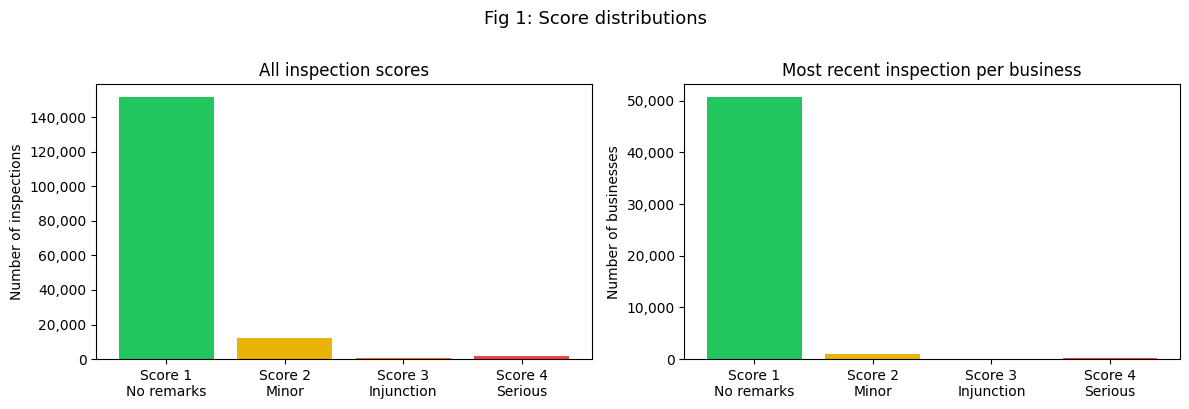

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
score_labels = {1.0: 'Score 1\nNo remarks', 2.0: 'Score 2\nMinor',
                3.0: 'Score 3\nInjunction', 4.0: 'Score 4\nSerious'}
colors = ['#22c55e', '#eab308', '#f97316', '#ef4444']

ax = axes[0]
counts = df['kontrol'].value_counts().sort_index()
ax.bar([score_labels[k] for k in counts.index], counts.values, color=colors[:len(counts)])
ax.set_title('All inspection scores', fontsize=12)
ax.set_ylabel('Number of inspections')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1]
counts2 = latest['kontrol'].value_counts().sort_index()
ax.bar([score_labels[k] for k in counts2.index], counts2.values, color=colors[:len(counts2)])
ax.set_title('Most recent inspection per business', fontsize=12)
ax.set_ylabel('Number of businesses')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Fig 1: Score distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


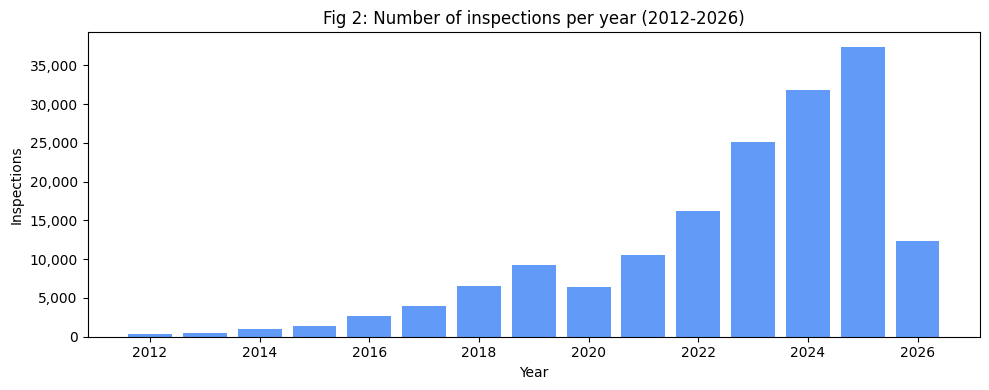

Note: the decline near 2026 reflects that we only have data through April 2026.


In [18]:
# Inspections per year
yearly = df.groupby(df['dato'].dt.year)['kontrol'].size()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly.index, yearly.values, color='#3b82f6', alpha=0.8)
ax.set_title('Fig 2: Number of inspections per year (2012-2026)', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Inspections')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print('Note: the decline near 2026 reflects that we only have data through April 2026.')


The apparent upward trend in inspections does not necessarily mean Denmark is inspecting more food businesses over time. It is largely an artifact of the dataset structure: Fødevarestyrelsen only stores the 4 most recent inspections per business. For businesses that have been around since 2012 and inspected regularly, only their most recent visits appear — which naturally cluster in recent years. Earlier inspections have simply been dropped from the dataset.
This means the chart should not be read as a time series of inspection activity. It is more accurately described as: "when were the most recent 4 inspections of currently active businesses conducted?" We include it here for transparency, but we do not use year as an analytical variable in our main analysis for this reason.

In [ ]:
# dreifing miðað við grúbbur

# 3 - Data Analysis
- Describe analysis and explain what you have learned
- Talk about machine learning if relevant

## 3. Data Analysis




# 4 - Genre 
- Which tools did you use for visual narrative and why?
- Which ... for narrative structure and why?

# 5 - Visualizations
- Explain the visualizations chosen
- Why are they right for the story we want to tell

# 6 - Discussion
- what went well
- what is missing and could be improved
- and why

# 7 - Contributions
- NOT okay that all contributed equally..

## 7. Contributions

| Member | Main responsibilities |
|---|---|
| **[Helga María Magnúsdóttir]** | |
| **[Hulda Ösp Ágústsdóttir]** | |
| **[Margrét Rán Rúnarsdóttir]** | |

setja inn dtu nr?

All group members contributed to the overall narrative structure of the website and reviewed each other's sections. The split above reflects who took primary responsibility for each component.
